# Tests `nn.CrossEntropyLoss()`

- Tests nn.CrossEntropyLoss() with a batch where, for each sample, the input has a high logit for a different class (simulates very confident predictions).
- The target for every sample is class 2, so only the sample where i=2 will be "correct"; others will purposely be wrong.
- The printed losses show how confident (or not) the loss function is under these conditions.


In [58]:
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
# Define the batch size and number of classes
batch_size = 5
num_classes = 5

# Generate random input logits with shape (batch_size, num_classes)
input = torch.randn(batch_size, num_classes)

# Create target tensor where all targets are class 2
target = (torch.zeros(batch_size) + 2).long()

# For each sample in the batch, make the correct class score much larger
# (simulate the model being highly confident for the correct class = i)
for i in range(num_classes):
    input[i, i] += 5.0  # Add a large value to the correct class score

print(input.shape)
print(target.shape)

torch.Size([5, 5])
torch.Size([5])


tensor([[ 5.8540, -1.1698, -0.3102, -0.0528,  0.2869],
        [-0.2273,  4.9788, -1.0940,  0.6904, -0.8361],
        [ 0.5368,  0.2252,  6.1831,  0.3255, -0.4185],
        [ 0.5403, -0.2251,  0.9724,  6.1733,  1.7056],
        [ 0.2090, -1.3012,  0.6700,  0.3479,  3.9500]])


Text(0.5, 1.0, 'Input Logits')

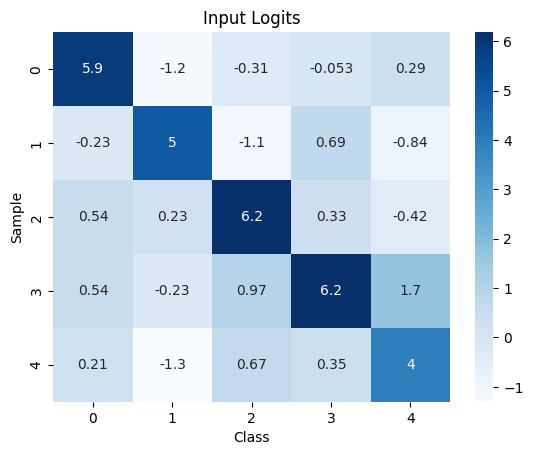

In [60]:
# Visualization of the input logits
print(input)
sns.heatmap(input, annot=True, cmap="Blues", cbar=True)
plt.xlabel("Class")
plt.ylabel("Sample")
plt.title("Input Logits")

In [61]:
print(target)

tensor([2, 2, 2, 2, 2])


In [62]:
# Initialize the CrossEntropyLoss function
loss = nn.CrossEntropyLoss()

losses = []
# Compute and print loss for each sample in the batch
for b in range(batch_size):
    # Pass one sample and its target at a time (unsqueeze(0) makes it a batch of 1, or a 2D tensor)
    output = loss(input[b, :].unsqueeze(0), target[b].unsqueeze(0))
    losses.append(output.item())

print(f"Losses: {losses}")

Losses: [6.173662185668945, 6.096962928771973, 0.010278387926518917, 5.222860336303711, 3.3697264194488525]


Text(0.5, 1.0, 'Loss for Each Sample in the Batch')

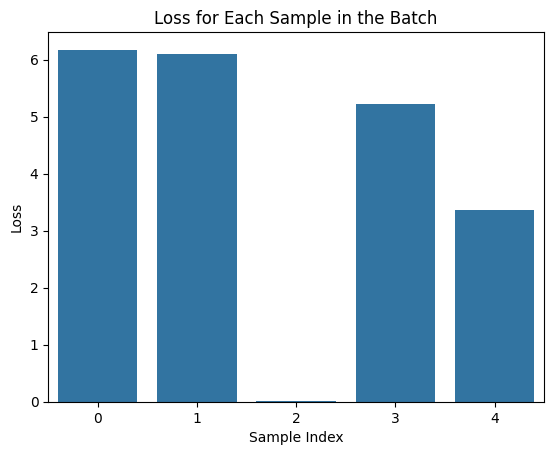

In [63]:
# Notice that the loss is small for Sample 2 (index 2) because the model is very confident about the correct class, 
# and the loss is larger for other samples where the model is less confident about the correct class.
sns.barplot(x=list(range(batch_size)), y=losses)
plt.xlabel("Sample Index")
plt.ylabel("Loss")
plt.title("Loss for Each Sample in the Batch")